In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data from previous pipeline step
if os.path.exists('pipeline_cost_output.csv'):
    df_churn = pd.read_csv('pipeline_cost_output.csv')
    print(f"Loaded {df_churn.shape[0]} rows from pipeline_cost_output.csv")
else:
    print("Error: pipeline_cost_output.csv not found. Please run cost_regression.ipynb first.")


Loaded 499 rows from pipeline_cost_output.csv


In [2]:
# Create a mock 'churn' target for demonstration if one doesn't exist
# E.g., assume high predicted duration and high cost leads to higher chance of churn
np.random.seed(42)
churn_prob = (df_churn['predicted_duration_mins'] / df_churn['predicted_duration_mins'].max()) * 0.4 + \
             (df_churn['predicted_amount'] / df_churn['predicted_amount'].max()) * 0.4 + \
             np.random.uniform(0, 0.2, size=len(df_churn))

df_churn['is_churned'] = (churn_prob > 0.5).astype(int)
print("Churn Distribution:")
print(df_churn['is_churned'].value_counts())


Churn Distribution:
is_churned
1    334
0    165
Name: count, dtype: int64


In [7]:
# Features and Target for Churn
features_churn = ['predicted_duration_mins', 'predicted_amount', 'base_price', 'base_duration_hours', 
                  'vehicle_age', 'vehicle_type_encoded']
target_churn = 'is_churned'

X_churn = df_churn[features_churn]
y_churn = df_churn[target_churn]

X_ch_train, X_ch_test, y_ch_train, y_ch_test = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42)

rf_churn = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_churn.fit(X_ch_train, y_ch_train)

y_ch_pred_train = rf_churn.predict(X_ch_train)
y_ch_pred_test = rf_churn.predict(X_ch_test)

# Analytics
print("\nClassification Report:")
print(classification_report(y_ch_test, y_ch_pred_test, zero_division=0))

print(f"{'Metric':<20} {'Train':>10} {'Test':>10}")
print(f"{'-'*42}")
print(f"  {'Accuracy':<20} {accuracy_score(y_ch_train, y_ch_pred_train):>10.4f} {accuracy_score(y_ch_test, y_ch_pred_test):>10.4f}")
print(f"  {'F1 Score':<20} {f1_score(y_ch_train, y_ch_pred_train):>10.4f} {f1_score(y_ch_test, y_ch_pred_test):>10.4f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.71      0.66        28
           1       0.88      0.82      0.85        72

    accuracy                           0.79       100
   macro avg       0.74      0.77      0.75       100
weighted avg       0.80      0.79      0.79       100

Metric                    Train       Test
------------------------------------------
  Accuracy                 1.0000     0.7900
  F1 Score                 1.0000     0.8489


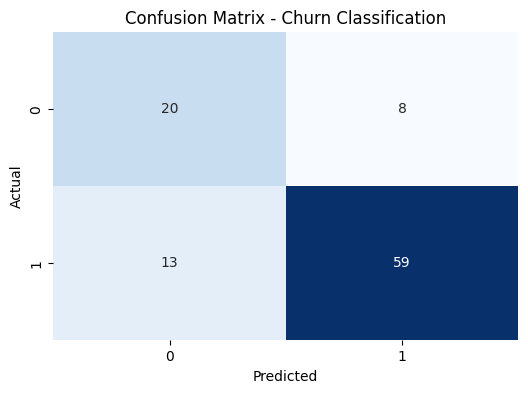

In [4]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_ch_test, y_ch_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Churn Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



Feature Importances (Churn Model):
                   Feature  Importance
0  predicted_duration_mins    0.416363
1         predicted_amount    0.339264
2               base_price    0.072805
4              vehicle_age    0.068717
3      base_duration_hours    0.061573
5     vehicle_type_encoded    0.041278


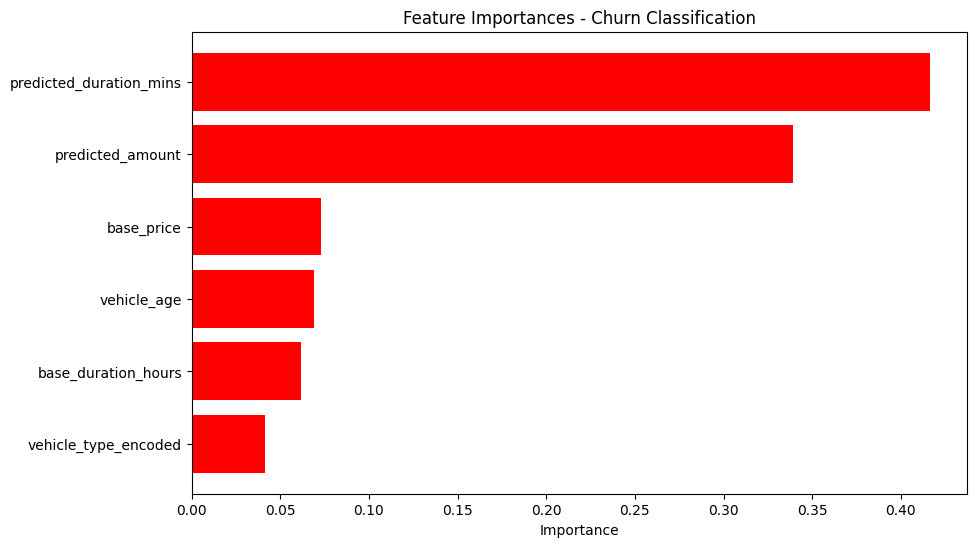

In [5]:
# Feature Importances for Churn
importances_ch = rf_churn.feature_importances_
feat_imp_ch = pd.DataFrame({'Feature': features_churn, 'Importance': importances_ch}).sort_values(by='Importance', ascending=False)
print("\nFeature Importances (Churn Model):")
print(feat_imp_ch)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_ch['Feature'], feat_imp_ch['Importance'], color='red')
plt.gca().invert_yaxis()
plt.title('Feature Importances - Churn Classification')
plt.xlabel('Importance')
plt.show()


In [6]:
import joblib
joblib.dump(rf_churn, 'exported/churn_model.pkl')

['exported/churn_model.pkl']